<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Computational Statistics / Metropolis-Hastings</h1>
<h3 style="margin: 0;  color: #1e1a66">Samoliuk Oleksandr</h3>
</div>

Imports:

In [1]:
import numpy as np
from scipy.stats import norm, skewnorm
from scipy.integrate import quad

import matplotlib.pyplot as plt
import seaborn as sns

---

In Bayesian inference, evaluating the posterior distribution $p(\theta\vert{}y) = \frac{p(y\vert{}\theta)p(\theta)}{p(y)}$ poses a fundamental computational challenge due to the intractability of the marginal likelihood $p(y) = \int p(y\vert{}\theta)p(\theta)d\theta$, particularly in high-dimensional or non-conjugate settings. Because this normalizing constant is generally unknown, standard sampling techniques such as inverse transform or accept-reject sampling cannot be applied. The Metropolis-Hastings (MH) algorithm circumvents this limitation by constructing a Markov chain to generate a set of posterior draws $\{\theta^{(1)}, \theta^{(2)}, \dots, \theta^{(M)}\}$ using exclusively the unnormalized numerator $p(y\vert{}\theta)p(\theta)$.

**Algorithm** Metropolis-Hastings Algorithm

* generate a Markov chain using proposal and acceptance steps
* Given current state $\nu^{(t)}$ for $t = 1, \dots, T$

Algorithm:

* for $t = 1, 2, \dots$ generate
  1. **Propose:** $\nu^{\text{new}} \sim q(\cdot \mid \nu^{\text{old}} = \nu^{(t)})$
  2. **Accept:**
     * $p(\nu^{(t+1)} = \nu^{\text{new}}) = \alpha(\nu^{\text{new}}, \nu^{\text{old}})$
     * $p(\nu^{(t+1)} = \nu^{\text{old}}) = 1 - \alpha(\nu^{\text{new}}, \nu^{\text{old}})$

Acceptance Ratio & Probability:

$$
\frac{f(\nu^{\text{new}})}{f(\nu^{\text{old}})} = \frac{\frac{p(y \mid \nu^{\text{new}}) p(\nu^{\text{new}})}{p(y)}}{\frac{p(y \mid \nu^{\text{old}}) p(\nu^{\text{old}})}{p(y)}} = \frac{p(y \mid \nu^{\text{new}}) p(\nu^{\text{new}})}{p(y \mid \nu^{\text{old}}) p(\nu^{\text{old}})}
\quad \longrightarrow \quad \alpha(\nu^{\text{new}}, \nu^{\text{old}}) = \min \left\{ \frac{f(\nu^{\text{new}}) q(\nu^{\text{old}} \mid \nu^{\text{new}})}{f(\nu^{\text{old}}) q(\nu^{\text{new}} \mid \nu^{\text{old}})}, 1 \right\}
$$

---

In [2]:
np.random.seed(35)
x = np.linspace(-9, 7, 3000)

n_s = 1000
mu, sigma = 1.0, 2.0
skew_param, step_sigma = 3.0, 2.5

def f(x, mu, sigma):
    return np.abs(norm.pdf(x, mu, sigma)*np.sin(3*x))**2 / 10

norm_constant, _ = quad(f, -np.inf, np.inf, args=(mu, sigma))

def f_normalized(x, mu, sigma):
    return f(x, mu, sigma) / norm_constant

def propose_skewed(x_old, a=skew_param, scale=step_sigma):
    return skewnorm.rvs(a=a, loc=x_old, scale=scale)

def q_skewed(x_new, x_old, a=skew_param, scale=step_sigma):
    return skewnorm.pdf(x_new, a=a, loc=x_old, scale=scale)


The loop:

In [3]:
def Metropolis_Hastings(n_iterations, sigma, skew_param, step_sigma):

    samples = np.zeros(n_iterations)
    samples[0] = 1.0

    for t in range(1, n_iterations):
        x_old = samples[t - 1]

        x_new = propose_skewed(x_old, skew_param, step_sigma)

        f_old = f_normalized(x_old, mu, sigma)                         # f(x_old)
        f_new = f_normalized(x_new, mu, sigma)                         # f(x_new)

        q_forward  = q_skewed(x_new, x_old, skew_param, step_sigma)    # q(x_new | x_old)
        q_backward = q_skewed(x_old, x_new, skew_param, step_sigma)    # q(x_old | x_new)

        alpha = min(1.0, (f_new / f_old) * (q_backward / q_forward))

        if np.random.uniform(0, 1) < alpha:
            samples[t] = x_new
        else:
            samples[t] = x_old

    samples_without_burnin = samples[2_000:]
    return samples_without_burnin, samples
    
    

Metropolis-Hastings:

In [10]:
n_iterations = 80_000
samples_without_burnin, samples = Metropolis_Hastings(n_iterations, sigma, skew_param, step_sigma)

Visuals:

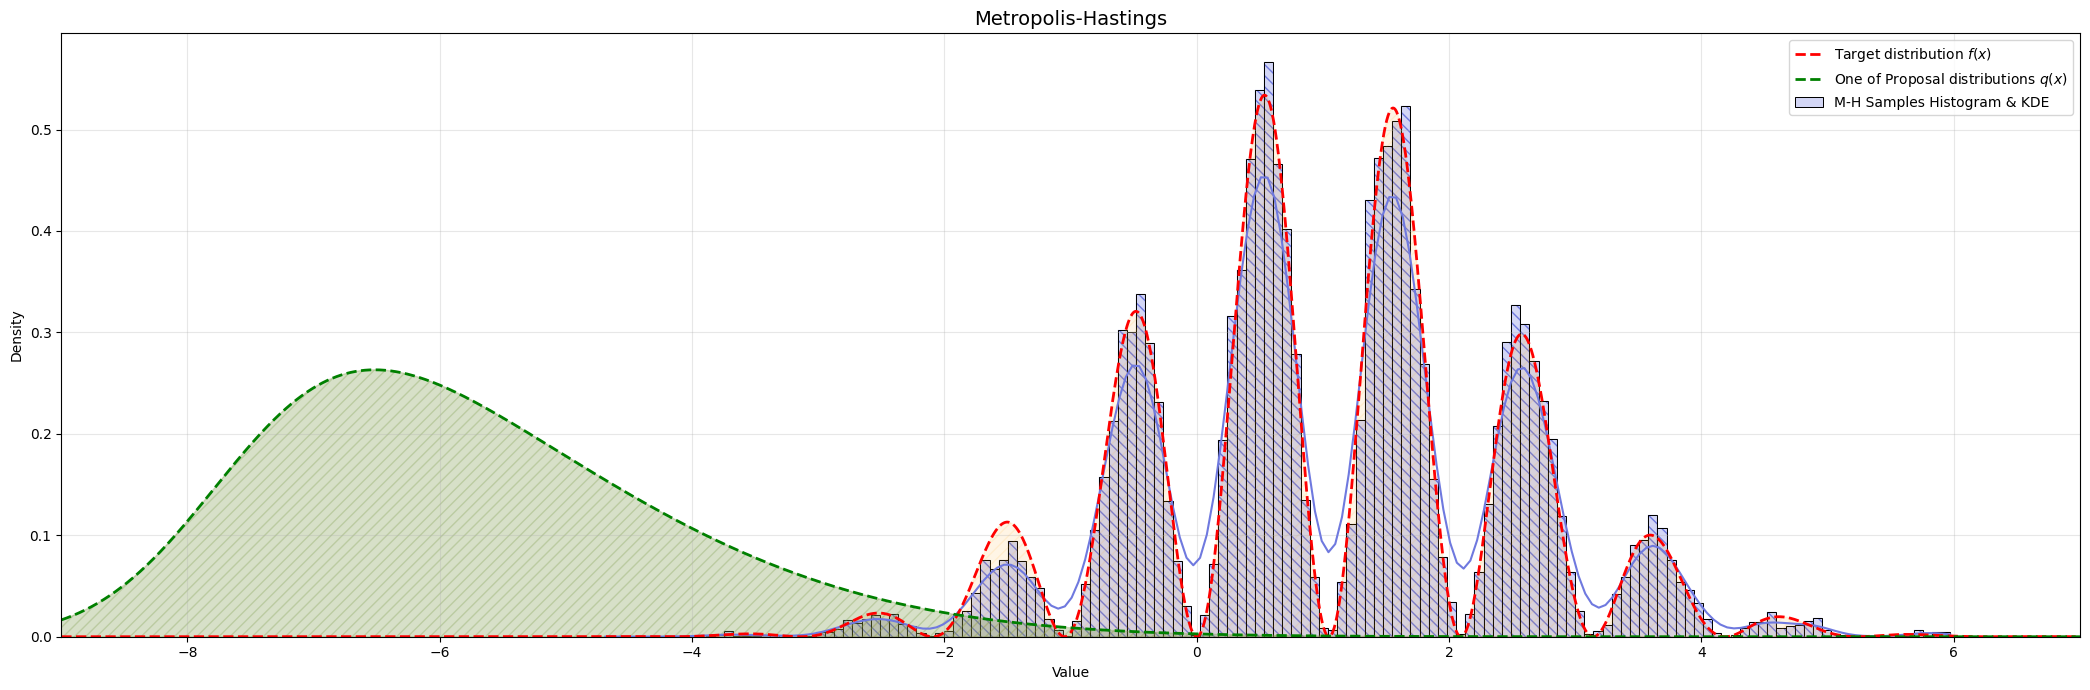

In [5]:
fig, ax = plt.subplots(figsize=(21, 7))
ax.set_title(f"Metropolis-Hastings", fontsize=14)

sns.histplot(
    data=samples_without_burnin,
    kde=True,
    stat="density",
    color="#6F79DF",
    fill=False,
    edgecolor="#6F79DF",
    hatch='\\\\\\',
    linewidth=0.1,
    ax=ax
)

sns.histplot(
    data=samples_without_burnin,
    kde=False,
    stat="density",
    color="#6F79DF",
    edgecolor="#000000",
    alpha=0.3,
    ax=ax,
    label="M-H Samples Histogram & KDE"
)

ax.plot(x, f_normalized(x, mu, sigma), "r--", label=f"Target distribution $f(x)$", linewidth=2, zorder=2)
ax.fill_between(x, f_normalized(x, mu, sigma), color='orange', alpha=0.1, hatch='///')

sp= -7.7
ax.plot(x, q_skewed(x, sp), "g--", label=f"One of Proposal distributions $q(x)$", linewidth=2, zorder=2)
ax.fill_between(x, q_skewed(x, sp), color="#7C9B4A", alpha=0.3, hatch='///')


ax.set_xlim(min(x), max(x))
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

plt.savefig('Outputs/Metropolis-Hastings/function_plots.png')
plt.show()

---

Let us now investigate the algorithm's behavior when transitions through the valleys are restricted:

In [6]:
n_iterations = 50_000
samples_diffsig = []
sigmas = [0.3, 0.7, 1, 1.3, 1.5, 1.7, 2.3]

for step_sigma in sigmas:

    samples_without_burnin, samples = Metropolis_Hastings(n_iterations, sigma, skew_param, step_sigma)
    samples_diffsig.append(samples_without_burnin)

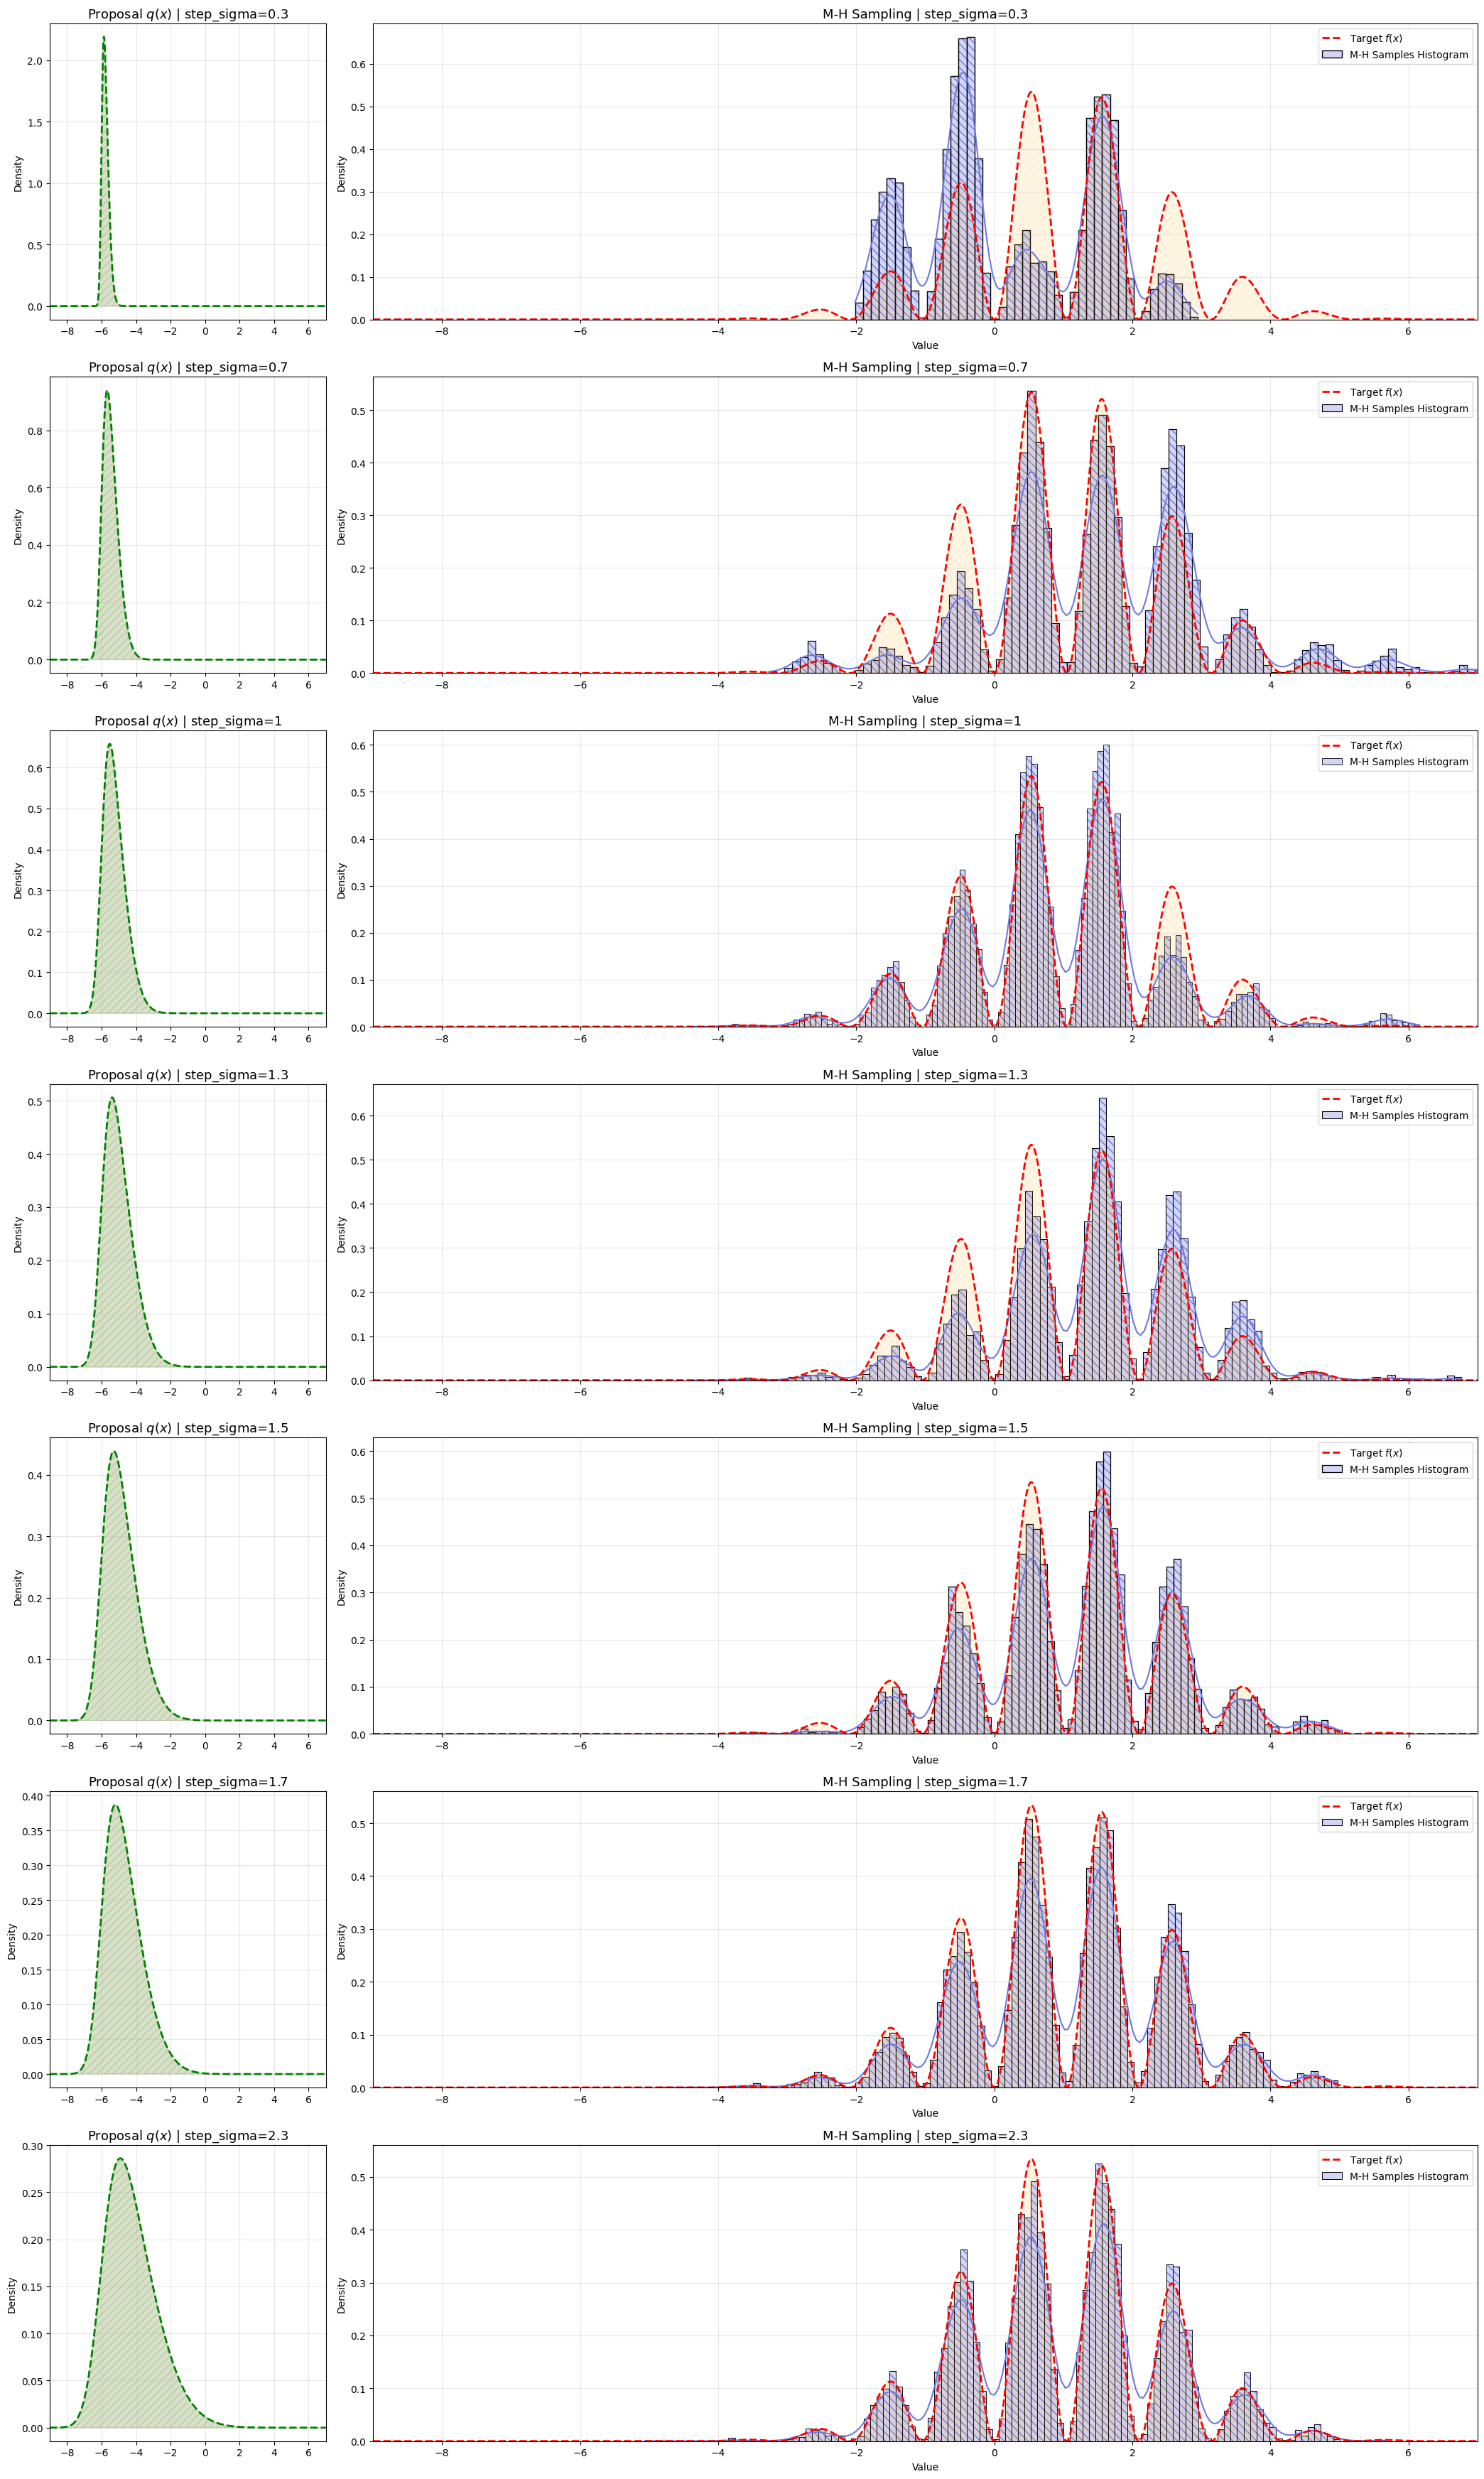

In [7]:
fig, axes = plt.subplots(
    nrows=len(sigmas), 
    ncols=2, 
    figsize=(21, 5 * len(sigmas)), 
    gridspec_kw={'width_ratios': [1, 4]}
)

for i, step_sigma in enumerate(sigmas):
 
    ax_left  = axes[i, 0]
    ax_right = axes[i, 1]

    center_val = -6
    q_vals = q_skewed(x, center_val, skew_param, step_sigma)
    
    ax_left.plot(x, q_vals, "g--", label=f"$q(x|\\mu)$", linewidth=2, zorder=2)
    ax_left.fill_between(x, q_vals, color="#7C9B4A", alpha=0.3, hatch='///')
    
    ax_left.set_title(f"Proposal $q(x)$ | step_sigma={step_sigma}", fontsize=13)
    ax_left.set_xlim(min(x), max(x))
    ax_left.set_ylabel("Density")
    ax_left.grid(True, alpha=0.3)
  
    sns.histplot(
        data=samples_diffsig[i],
        kde=True,
        stat="density",
        color="#6F79DF",
        fill=False,
        edgecolor="#6F79DF",
        hatch='\\\\\\',
        linewidth=0.1,
        ax=ax_right
    )
    
    sns.histplot(
        data=samples_diffsig[i],
        kde=False,
        stat="density",
        color="#6F79DF",
        edgecolor="#000000",
        alpha=0.3,
        ax=ax_right,
        label="M-H Samples Histogram"
    )
    
    ax_right.plot(x, f_normalized(x, mu, sigma), "r--", label="Target $f(x)$", linewidth=2, zorder=2)
    ax_right.fill_between(x, f_normalized(x, mu, sigma), color='orange', alpha=0.1, hatch='///')
    
    ax_right.set_title(f"M-H Sampling | step_sigma={step_sigma}", fontsize=13)
    ax_right.set_xlim(min(x), max(x))
    ax_right.set_xlabel("Value")
    ax_right.set_ylabel("Density")
    ax_right.legend(loc="upper right")
    ax_right.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig('Outputs/Metropolis-Hastings/M-H_stepsizes.png')
plt.show()

### Effect of Proposal Step Size on Metropolis-Hastings Sampling

To evaluate how proposal step size impacts MH performance, the chain was run across `step_sigma` $\in \{0.3, 0.7, 1.0, 1.3, 1.5, 1.7, 2.3\}$. The left panels display the proposal density $q(x)$, and the right panels compare the resulting sample histogram against the target distribution $f(x)$.

* **Small step (0.3):** Proposals rarely cross between modes, causing poor mixing and density mismatches as the chain over- or under-represents local peaks.
* **Intermediate step (1.0–1.7):** The step size is wide enough to jump between adjacent modes while maintaining a healthy acceptance rate, allowing the histogram to accurately track the target.
* **Large step (2.3):** Proposals frequently overshoot into low-density regions, driving up rejection rates and adding noise to the outer modes due to fewer effective draws.

This illustrates the classic MH trade-off: small steps cause slow mixing, large steps waste proposals via high rejection rates, and intermediate steps strike the optimal balance.

---

Trace plots:

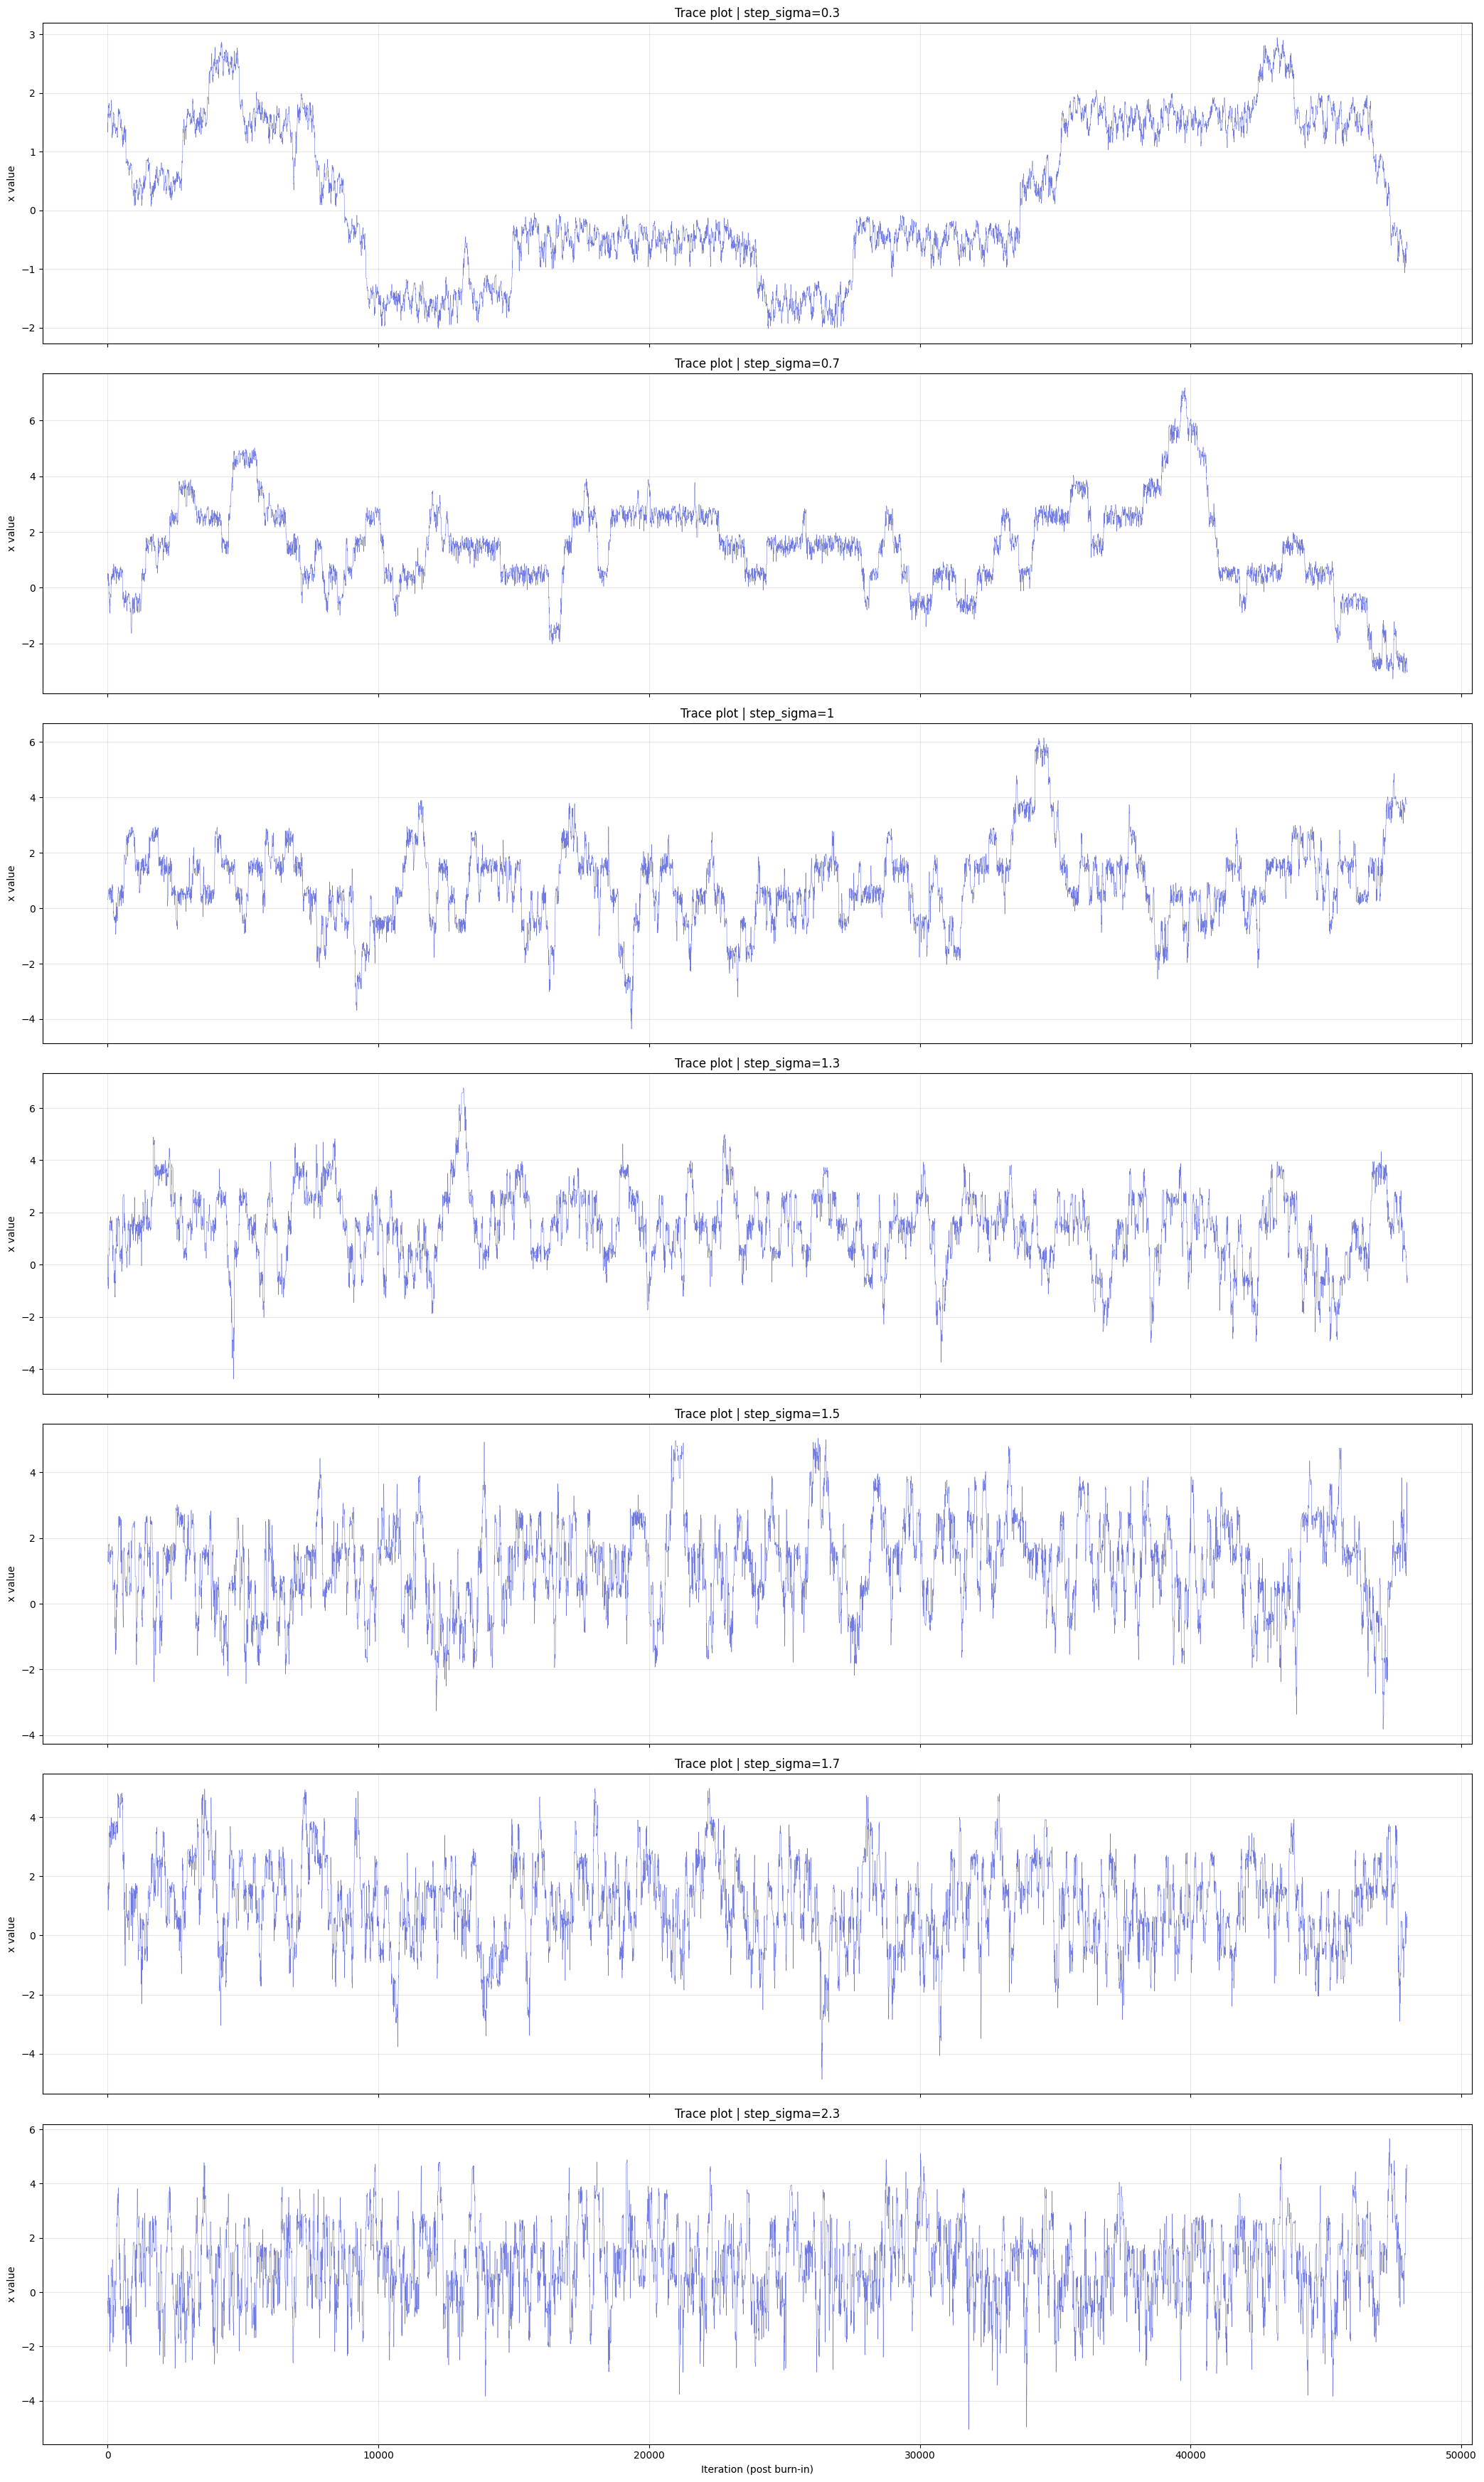

In [8]:
fig, ax = plt.subplots(nrows=len(sigmas), ncols=1, figsize=(21, 5 * len(sigmas)), sharex=True)

for i, step_sigma in enumerate(sigmas):
    ax[i].plot(samples_diffsig[i], lw=0.4, color="#6F79DF")
    ax[i].set_title(f"Trace plot | step_sigma={step_sigma}")
    ax[i].set_ylabel("x value")
    ax[i].grid(alpha=0.3)

ax[-1].set_xlabel("Iteration (post burn-in)")
fig.tight_layout()
plt.savefig('Outputs/Metropolis-Hastings/trace_plots.png')
plt.show()

The trace plots show how mixing speed changes with `step_sigma`. For small values (0.3–0.7), the chain gets stuck in one region for long stretches before jumping to another, producing visible plateaus — a sign of high autocorrelation and poor mixing. As `step_sigma` increases, these plateaus shrink and the trace becomes denser and more erratic, closer to the pattern of a well-mixing chain. Larger step sizes also let the chain reach more distant, low-density regions that small steps rarely visit, which is why the range of sampled values widens as `step_sigma` grows. Overall, the plots confirm that larger step sizes here lead to faster, more efficient exploration of the target.

---